# Notebook 3: Explore and Validate Readability

## 1. Setup

Import libraries.

In [1]:
import os
import pandas as pd
import textstat
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Cleaned Dataset

In [2]:
# Load final cleaned dataset (from Notebook 2)
df = pd.read_csv("../preprocessing_data/processed_texts_final.csv")

In [3]:
# Create folders for output
os.makedirs("analysis_outputs/plots", exist_ok=True)
os.makedirs("analysis_outputs/outliers", exist_ok=True)

## 3. Boxplots: CEFR vs FK Scores

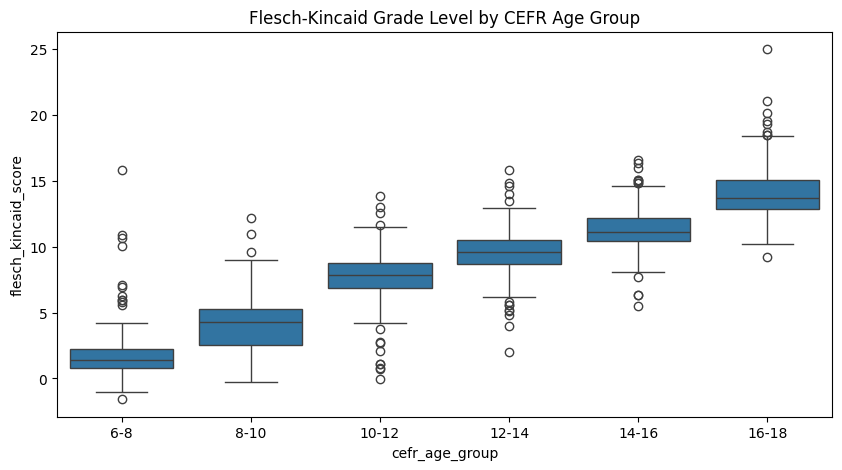

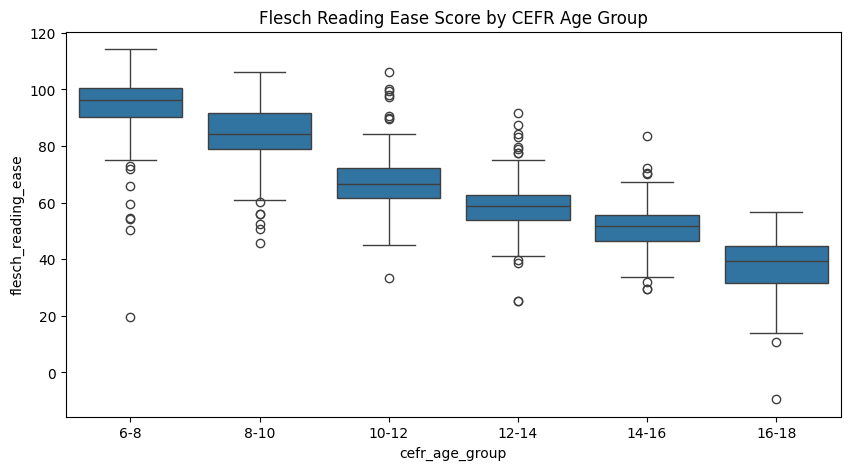

In [13]:
### STEP 2: Plot by Original CEFR Age Group

age_order = ['6-8', '8-10', '10-12', '12-14', '14-16', '16-18']

plt.figure(figsize=(10,5))
sns.boxplot(x='cefr_age_group', y='flesch_kincaid_score', data=df, order=age_order)
plt.title('Flesch-Kincaid Grade Level by CEFR Age Group')
plt.savefig("analysis_outputs/plots/fk_by_cefr_age_group.png")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='cefr_age_group', y='flesch_reading_ease', data=df, order=age_order)
plt.title('Flesch Reading Ease Score by CEFR Age Group')
plt.savefig("analysis_outputs/plots/fre_by_cefr_age_group.png")
plt.show()

## 4. Outlier Detection (Pre-Banding)

In [5]:
### STEP 3: Detect Outliers (Pre-FK Banding, by CEFR Group)
outliers_cefr = pd.DataFrame()
for group in df['cefr_age_group'].unique():
    group_df = df[df['cefr_age_group'] == group]
    Q1 = group_df['flesch_kincaid_score'].quantile(0.25)
    Q3 = group_df['flesch_kincaid_score'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    group_outliers = group_df[(group_df['flesch_kincaid_score'] < lower) | (group_df['flesch_kincaid_score'] > upper)]
    outliers_cefr = pd.concat([outliers_cefr, group_outliers])

outliers_cefr.to_csv("analysis_outputs/outliers/cefr_outliers.csv", index=False)

## 5. Reapply Banding

In [6]:
band_order = ["≤5", "6-7", "8-12", "13-14", "15-16", "17-18", ">18"]
df["reading_band"] = pd.Categorical(df["reading_band"], categories=band_order, ordered=True)

## 6. Boxplots: FK-Derived Reading Bands

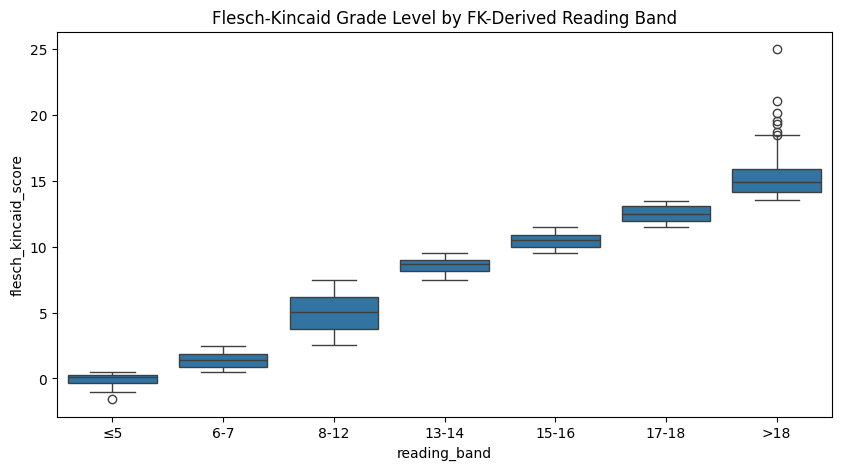

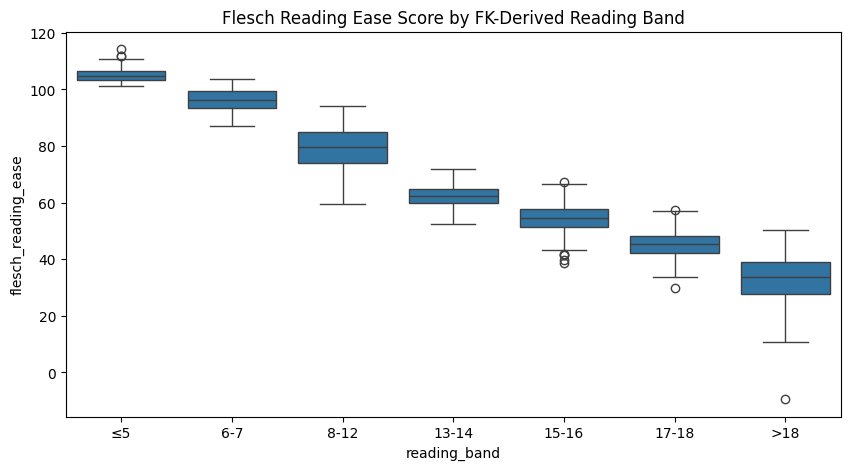

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(x='reading_band', y='flesch_kincaid_score', data=df, order=band_order)
plt.title('Flesch-Kincaid Grade Level by FK-Derived Reading Band')
plt.savefig("analysis_outputs/plots/fk_by_fk_band.png")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='reading_band', y='flesch_reading_ease', data=df, order=band_order)
plt.title('Flesch Reading Ease Score by FK-Derived Reading Band')
plt.savefig("analysis_outputs/plots/fre_by_fk_band.png")
plt.show()

## 7. Outlier Detection (Post-Banding)

In [8]:
outliers_fk = pd.DataFrame()
for group in df['reading_band'].unique():
    group_df = df[df['reading_band'] == group]
    Q1 = group_df['flesch_kincaid_score'].quantile(0.25)
    Q3 = group_df['flesch_kincaid_score'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    group_outliers = group_df[(group_df['flesch_kincaid_score'] < lower) | (group_df['flesch_kincaid_score'] > upper)]
    outliers_fk = pd.concat([outliers_fk, group_outliers])

outliers_fk.to_csv("analysis_outputs/outliers/fk_band_outliers.csv", index=False)


## 8. Comparison: CEFR vs FK-Derived Groupings

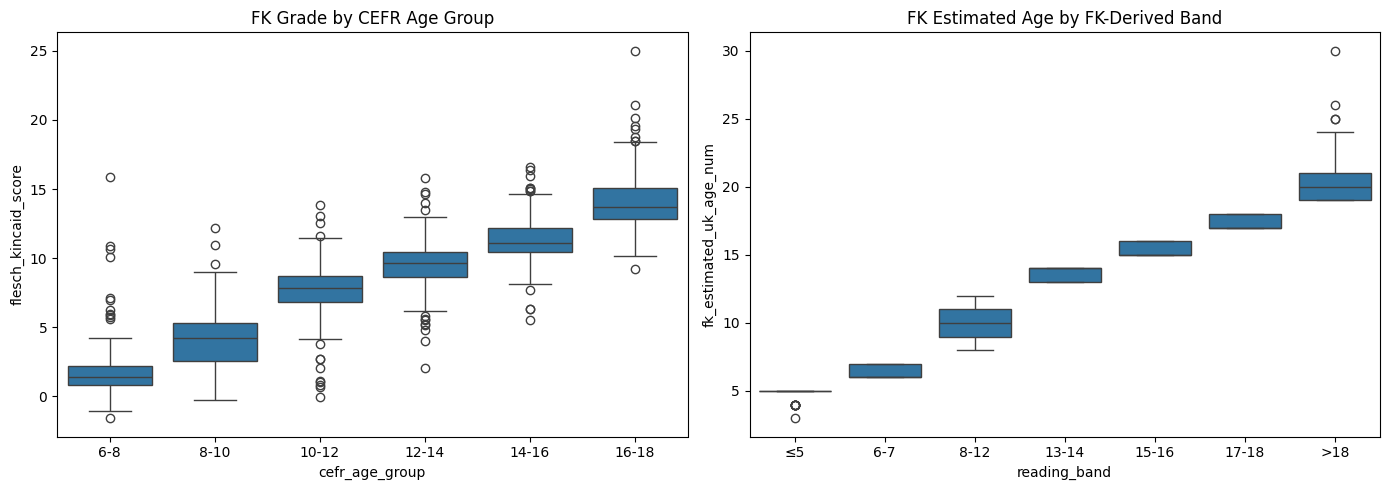

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="cefr_age_group", y="flesch_kincaid_score", data=df, ax=axes[0])
axes[0].set_title("FK Grade by CEFR Age Group")

sns.boxplot(x="reading_band", y="fk_estimated_uk_age_num", data=df, ax=axes[1])
axes[1].set_title("FK Estimated Age by FK-Derived Band")

plt.tight_layout()
plt.savefig("analysis_outputs/plots/side_by_side_fk_cefr_vs_bands.png")
plt.show()

In [10]:
print(f"CEFR outliers: {len(outliers_cefr)}")
print(f"FK band outliers: {len(outliers_fk)}")

CEFR outliers: 62
FK band outliers: 8


## 9. Explore Feature Correlations


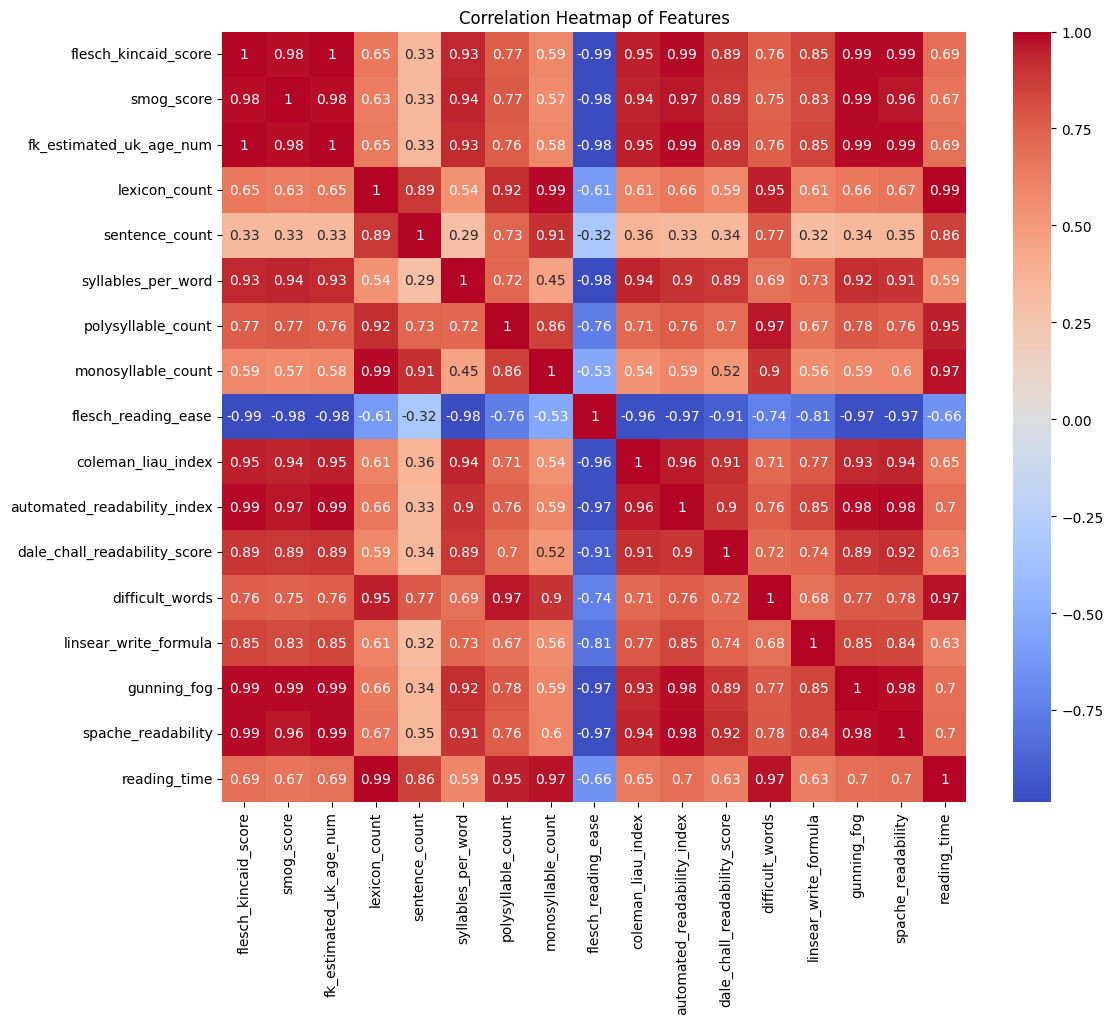

In [11]:
# Load your data
df = pd.read_csv("processed_texts_final.csv")

# Select numeric columns only for correlation
numeric_cols = df.select_dtypes(include='number')

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.savefig("analysis_outputs/plots/correlation_heatmap.png")
plt.show()

## 10. Visualize Feature Distributions and Relationships by Reading Band

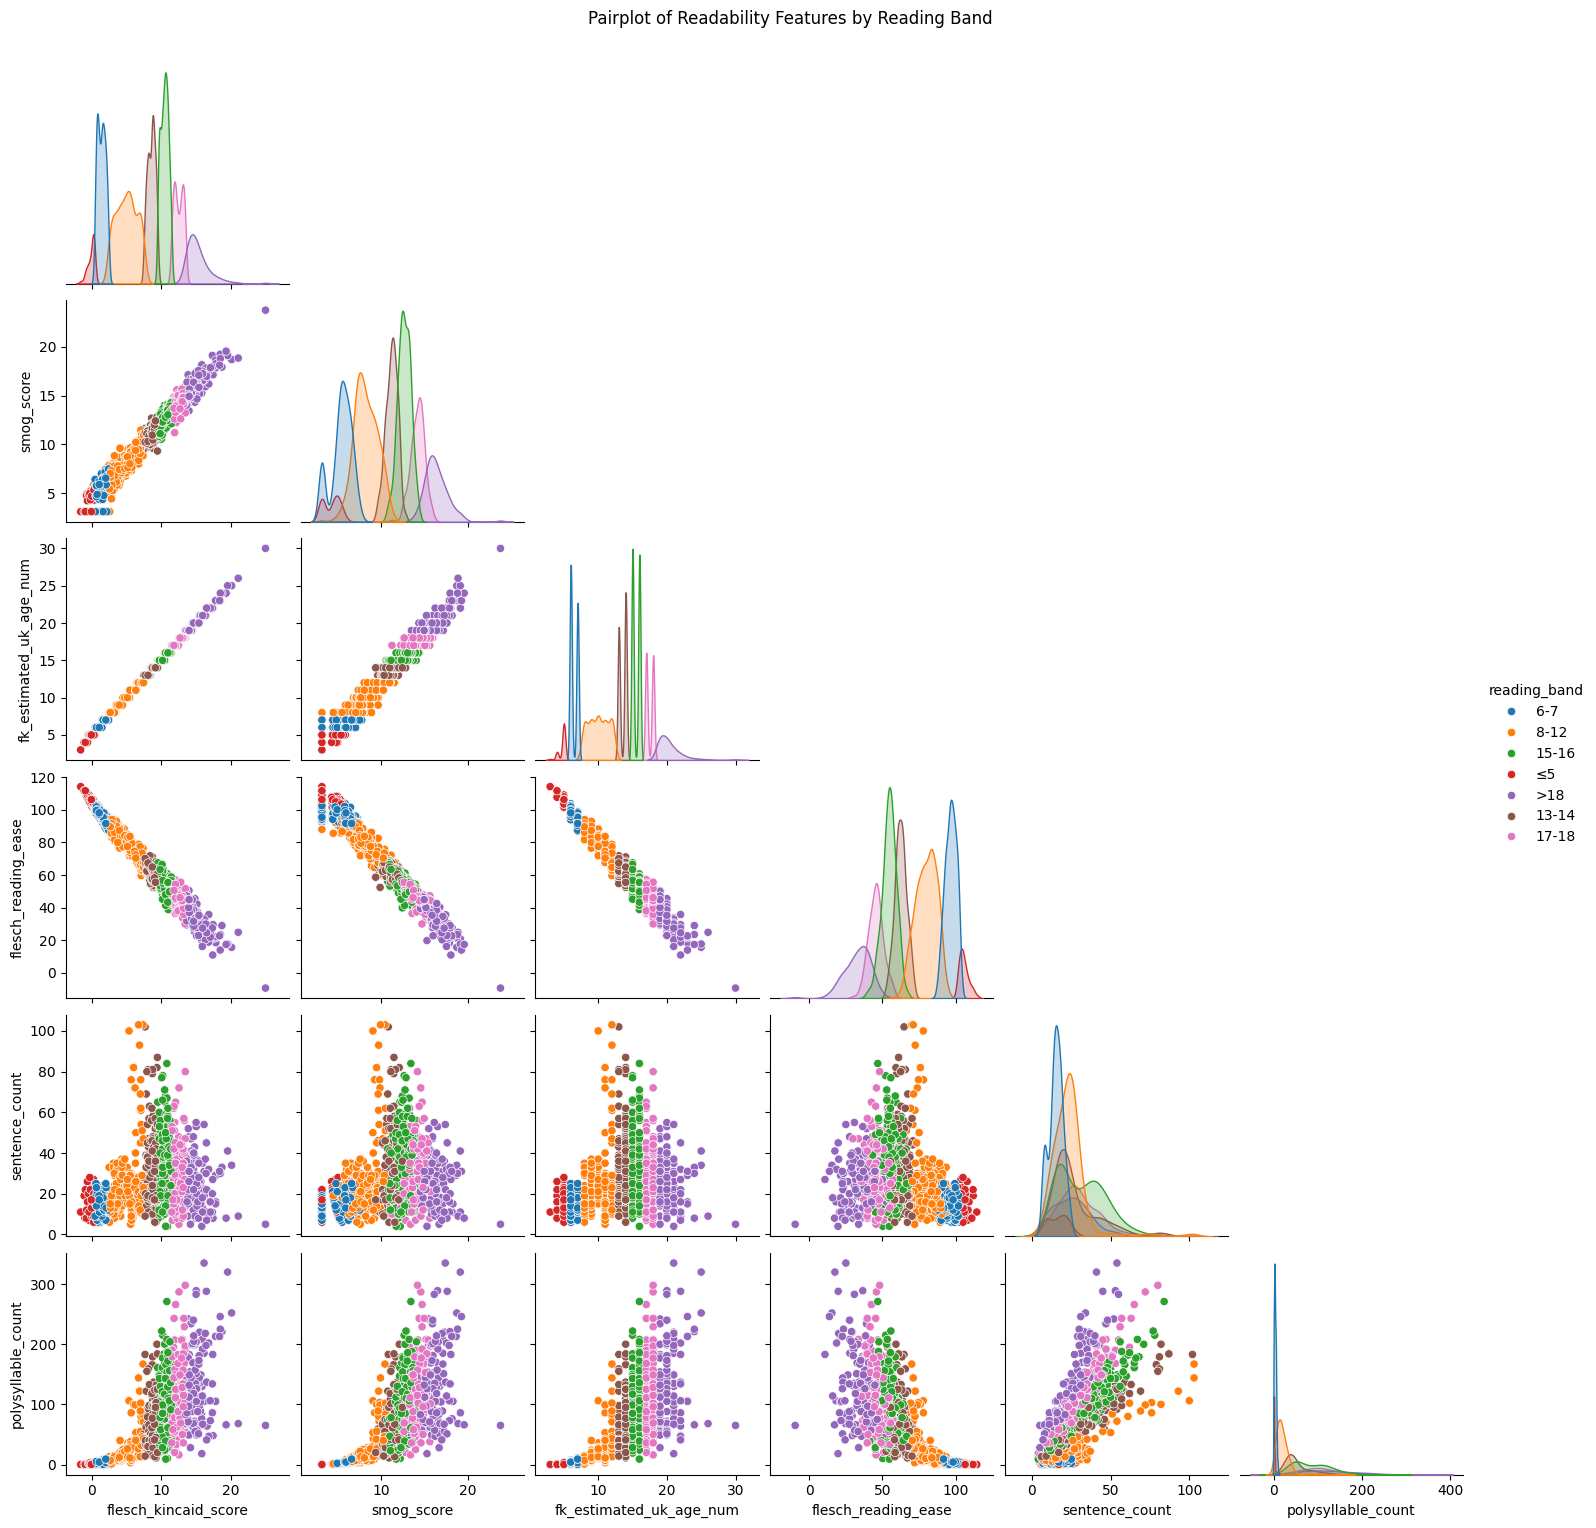

In [12]:
# Choose your features (update this list to your preference)
features = [
    "flesch_kincaid_score", "smog_score", "fk_estimated_uk_age_num",
    "flesch_reading_ease", "sentence_count", "polysyllable_count"
]

sns.pairplot(df[features + ["reading_band"]], hue="reading_band", diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Readability Features by Reading Band", y=1.02)
plt.savefig("analysis_outputs/plots/pairplot_readability_features.png")
plt.show()